# 日常回测控制台

这份 notebook 用于**日常使用**，目标是尽量少切换 cell，直接完成：

1. 读取本地市场数据  
2. 设置资产池与回测参数  
3. 运行风险平价回测  
4. 查看关键结果  
5. 导出回测结果

> 依赖：`market_data.py`、`backtest.py`、`risk_parity.py`


In [ ]:

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import create_manager, today_str, load_tushare_token
from backtest import build_market_matrices, simulate_risk_parity_backtest, calc_drawdown

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# ========= 路径与连接 =========
TUSHARE_TOKEN = load_tushare_token()
DB_PATH = "data/db/market_data.db"
EXPORT_DIR = Path("data/exports_risk_parity")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

manager = create_manager(
    tushare_token=TUSHARE_TOKEN,
    db_path=DB_PATH,
    default_start_date="20150101",
    default_exchange="SSE",
)

print("manager ready")
print("db_path =", Path(DB_PATH).resolve())
print("export_dir =", EXPORT_DIR.resolve())


manager ready
db_path = D:\codeWork\RiskParity\data\db\market_data.db
export_dir = D:\codeWork\RiskParity\data\exports


In [2]:

# ========= 资产池 =========

#以下为无杠杆全天候国内260324版本
WATCHLIST = [
    "510300.SH",  # 沪深300ETF (核心权益：大盘蓝筹)
    #"510500.SH",  # 中证500ETF (核心权益：中盘成长)
    #"510170.SH",  # 50ETF (核心权益：大宗商品股票集合)
    #"159915.SZ",  # 创业板ETF (核心权益：高新成长 - 纯被动)
    "511090.SH",  # 30年国债ETF (避险资产：超长债，对利率极度敏感)
    #"511010.SH",  # 国债ETF (基础配置：中长期债)
    "518880.SH",  # 黄金ETF (抗通胀/避险：金属商品)
    "159981.SZ",  # 能源ETF (抗通胀：能源/电力)
    "159985.SZ",  # 豆粕ETF (抗通胀：农产品期货)
    "501018.SH",  # 南方原油LOF (抗通胀：国际原油价格)
    "515100.SH",  # 红利低波100ETF (抗通胀：红利股)
]
# ========= 数据区间 =========
START_DATE = "20230101"
END_DATE = today_str()

# ========= 回测参数 =========
BACKTEST_PARAMS = {
    "initial_cash": 1_000_000.0,
    #"initial_cash": 30_000.0,
    "lookback_window": 120,
    "rebalance_freq": "M",          # D / W / M / Q / Y
    "execution_price_type": "avg",  # open / close / high / low / avg
    "fee_rate_buy": 0.0005,
    "fee_rate_sell": 0.0005,
    "lot_size": 100,
    "max_trade_amount_ratio": 0.05,
    "amount_unit_scale": 1000.0,# 按照tushare文档，单位似乎是千元？
    "use_drift_trigger": False,
    "drift_threshold": 0.05,
    "risk_free_rate": 0.0,#设置为0，计算的夏普率就是“收益风险比”
    "annualization": 252,
}

RP_PREPARE_KWARGS = {
    "ffill": True,
    "ffill_limit": 5,
    "min_non_na_ratio": 0.8,
    "drop_all_na_dates": True,

}
valuation_ffill_limit = 5
RP_WEIGHT_KWARGS = {
    "method": "sample",      # sample / ewma
    "return_type": "log",    # log / simple
    "annualization": 252,
    "long_only": True,
    "drop_any_na": True,
}

print("watchlist =", WATCHLIST)
print("params loaded")


watchlist = ['510300.SH', '511090.SH', '518880.SH', '159981.SZ', '159985.SZ', '501018.SH', '515100.SH']
params loaded


In [3]:

# ========= 读取市场数据并构建 market 字典 =========
raw_prices = manager.store.get_daily_prices(
    ts_codes=WATCHLIST,
    start_date=START_DATE,
    end_date=END_DATE,
)

print("raw_prices shape =", raw_prices.shape)
display(raw_prices.head())

coverage = raw_prices.groupby("ts_code")["trade_date"].agg(["min", "max", "count"])
display(coverage)

market = build_market_matrices(
    data=raw_prices,
    fields=("open", "high", "low", "close", "amount"),
    date_col="trade_date",
    code_col="ts_code",
    date_format="%Y%m%d",
)

RP_PREPARE_KWARGS["calendar"] = market["close"].index

for k, v in market.items():
    print(k, v.shape)


raw_prices shape = (5352, 14)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,source,created_at,updated_at
0,159981.SZ,20230103,1.504,1.521,1.496,1.521,1.512,0.009,0.5952,159606.0,24134.559,tushare,2026-03-24 20:53:48,2026-03-24 23:15:17
1,159981.SZ,20230104,1.512,1.512,1.495,1.500,1.521,-0.021,-1.3807,142289.0,21372.901,tushare,2026-03-24 20:53:48,2026-03-24 23:15:17
2,159981.SZ,20230105,1.491,1.493,1.477,1.483,1.500,-0.017,-1.1333,119346.0,17705.581,tushare,2026-03-24 20:53:48,2026-03-24 23:15:17
3,159981.SZ,20230106,1.481,1.492,1.475,1.490,1.483,0.007,0.4720,138691.0,20586.237,tushare,2026-03-24 20:53:48,2026-03-24 23:15:17
4,159981.SZ,20230109,1.485,1.485,1.467,1.474,1.490,-0.016,-1.0738,235935.0,34755.888,tushare,2026-03-24 20:53:48,2026-03-24 23:15:17


,min,max,count
ts_code,,,
159981.SZ,20230103,20260326,780
159985.SZ,20230103,20260326,780
501018.SH,20230103,20260326,778
510300.SH,20230103,20260326,780
511090.SH,20230613,20260326,674
515100.SH,20230103,20260326,780
518880.SH,20230103,20260326,780


open (780, 7)
high (780, 7)
low (780, 7)
close (780, 7)
amount (780, 7)


In [4]:

# ========= 运行回测 =========
result = simulate_risk_parity_backtest(
    market=market,
    initial_cash=BACKTEST_PARAMS["initial_cash"],
    lookback_window=BACKTEST_PARAMS["lookback_window"],
    rebalance_freq=BACKTEST_PARAMS["rebalance_freq"],
    execution_price_type=BACKTEST_PARAMS["execution_price_type"],
    fee_rate_buy=BACKTEST_PARAMS["fee_rate_buy"],
    fee_rate_sell=BACKTEST_PARAMS["fee_rate_sell"],
    lot_size=BACKTEST_PARAMS["lot_size"],
    max_trade_amount_ratio=BACKTEST_PARAMS["max_trade_amount_ratio"],
    amount_unit_scale=BACKTEST_PARAMS["amount_unit_scale"],
    use_drift_trigger=BACKTEST_PARAMS["use_drift_trigger"],
    drift_threshold=BACKTEST_PARAMS["drift_threshold"],
    rp_prepare_kwargs=RP_PREPARE_KWARGS,
    rp_weight_kwargs=RP_WEIGHT_KWARGS,
    risk_free_rate=BACKTEST_PARAMS["risk_free_rate"],
    annualization=BACKTEST_PARAMS["annualization"],
    valuation_ffill_limit=valuation_ffill_limit,
)

summary = result["summary"]
nav_df = result["nav_df"]
returns = result["returns"]
weights_df = result["weights_df"]
positions_df = result["positions_df"]
target_weights_df = result["target_weights_df"]
trades_df = result["trades_df"]
rebalance_log_df = result["rebalance_log_df"]
asset_corr_matrix = result["asset_corr_matrix"]
risk_contribution_df = result["risk_contribution_df"]

print("回测完成")
display(summary.to_frame("value"))


回测完成


,value
total_return,0.272863
annual_return,0.081175
excess_return,0.081175
annual_volatility,0.067872
sharpe_ratio,1.182548
max_drawdown,-0.058754
calmar_ratio,-1.381617
avg_asset_correlation,0.075804


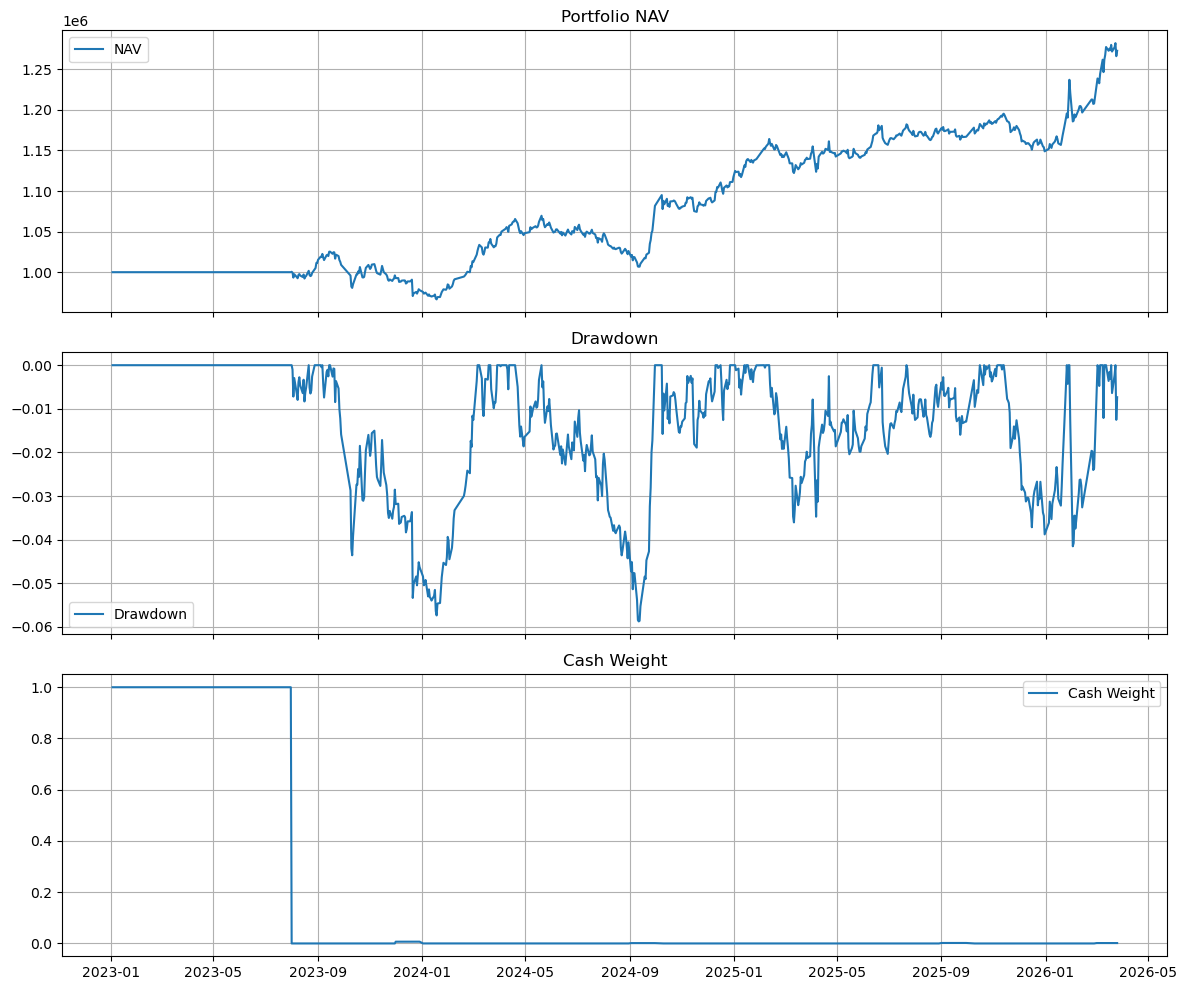

最近净值：


,nav,cash
trade_date,,
2026-03-20,1.271932e+06,2024.67025
2026-03-23,1.277189e+06,2024.67025
2026-03-24,1.282277e+06,2024.67025
2026-03-25,1.266210e+06,2024.67025
2026-03-26,1.272863e+06,2024.67025


最近现金占比：


,cash_weight
trade_date,
2026-03-20,0.001592
2026-03-23,0.001585
2026-03-24,0.001579
2026-03-25,0.001599
2026-03-26,0.001591


最近目标权重：


...

最近调仓日志：


,signal_date,trade_date,reason,drift_value,turnover,cash_after_trade,traded,trade_count
22,2025-05-30,2025-06-03,schedule,NaN,0.056763,112.570600,1,137
23,2025-06-30,2025-07-01,schedule,NaN,0.101535,2.229263,1,42
24,2025-07-31,2025-08-01,schedule,NaN,0.070074,8.724363,1,29
25,2025-08-29,2025-09-01,schedule,NaN,0.065522,2279.266600,1,147
26,2025-09-30,2025-10-09,schedule,NaN,0.159480,1.339738,1,570
27,2025-10-31,2025-11-03,schedule,NaN,0.062587,84.727788,1,173
28,2025-11-28,2025-12-01,schedule,NaN,0.031755,68.114613,1,67
29,2025-12-31,2026-01-05,schedule,NaN,0.137352,106.742338,1,692
30,2026-01-30,2026-02-02,schedule,NaN,0.177624,65.699400,1,472
31,2026-02-27,2026-03-02,schedule,NaN,0.148159,2024.670250,1,113


最近交易记录：


,trade_date,ts_code,side,price,shares,trade_value,cost
10790,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10791,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10792,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10793,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10794,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10795,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10796,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10797,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10798,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200
10799,2026-03-02,159985.SZ,BUY,2.0240,100,202.40,0.101200


平均现金占比： 0.178573796927398
最大现金占比： 1.0


In [5]:
# ========= 日常查看：净值 / 回撤 / 现金占比 / 最近调仓 / 最近交易 =========
drawdown = calc_drawdown(nav_df["nav"])
cash_weight = nav_df["cash"] / nav_df["nav"]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. 净值
axes[0].plot(nav_df.index, nav_df["nav"], label="NAV")
axes[0].set_title("Portfolio NAV")
axes[0].legend()

# 2. 回撤
axes[1].plot(drawdown.index, drawdown, label="Drawdown")
axes[1].set_title("Drawdown")
axes[1].legend()

# 3. 现金占比
axes[2].plot(cash_weight.index, cash_weight, label="Cash Weight")
axes[2].set_title("Cash Weight")
axes[2].legend()

plt.tight_layout()
plt.show()

print("最近净值：")
display(nav_df.tail())

print("最近现金占比：")
display(cash_weight.tail().to_frame("cash_weight"))

print("最近目标权重：")
display(target_weights_df.tail())

print("最近实际权重：")
display(weights_df.tail())

print("最近持仓：")
display(positions_df.tail())

print("最近调仓日志：")
display(rebalance_log_df.tail(10))

print("最近交易记录：")
display(trades_df.tail(20))

print("平均现金占比：", cash_weight.mean())
print("最大现金占比：", cash_weight.max())

In [6]:

# ========= 一键导出 =========
nav_df.to_csv(EXPORT_DIR / "nav.csv")
weights_df.to_csv(EXPORT_DIR / "weights.csv")
positions_df.to_csv(EXPORT_DIR / "positions.csv")
target_weights_df.to_csv(EXPORT_DIR / "target_weights.csv")
trades_df.to_csv(EXPORT_DIR / "trades.csv", index=False)
rebalance_log_df.to_csv(EXPORT_DIR / "rebalance_log.csv", index=False)
summary.to_csv(EXPORT_DIR / "summary.csv")

asset_corr_matrix.to_csv(EXPORT_DIR / "asset_corr_matrix.csv")
risk_contribution_df.to_csv(EXPORT_DIR / "risk_contribution_df.csv")

print("export done")


export done


In [7]:

# ========= 可选：快速改参数重跑 =========
# 这里只留一个最常用示例，避免 notebook 过长

# BACKTEST_PARAMS["rebalance_freq"] = "M"
# BACKTEST_PARAMS["use_drift_trigger"] = True
# BACKTEST_PARAMS["drift_threshold"] = 0.08
# RP_WEIGHT_KWARGS["method"] = "ewma"

# result = simulate_risk_parity_backtest(
#     market=market,
#     initial_cash=BACKTEST_PARAMS["initial_cash"],
#     lookback_window=BACKTEST_PARAMS["lookback_window"],
#     rebalance_freq=BACKTEST_PARAMS["rebalance_freq"],
#     execution_price_type=BACKTEST_PARAMS["execution_price_type"],
#     fee_rate_buy=BACKTEST_PARAMS["fee_rate_buy"],
#     fee_rate_sell=BACKTEST_PARAMS["fee_rate_sell"],
#     lot_size=BACKTEST_PARAMS["lot_size"],
#     max_trade_amount_ratio=BACKTEST_PARAMS["max_trade_amount_ratio"],
#     amount_unit_scale=BACKTEST_PARAMS["amount_unit_scale"],
#     use_drift_trigger=BACKTEST_PARAMS["use_drift_trigger"],
#     drift_threshold=BACKTEST_PARAMS["drift_threshold"],
#     rp_prepare_kwargs=RP_PREPARE_KWARGS,
#     rp_weight_kwargs=RP_WEIGHT_KWARGS,
#     risk_free_rate=BACKTEST_PARAMS["risk_free_rate"],
#     annualization=BACKTEST_PARAMS["annualization"],
# )
